In [96]:
import matplotlib.pyplot as plt
%cd ..
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
%load_ext autoreload
%autoreload 2

/home
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import json
import glob
import pandas as pd 
import numpy as np
from collections import defaultdict
from benchmark.plots.matrix_matrix import *


def rename_colum(df, old_name, new_name):

    df["Type"] = df["Type"].apply(lambda x: x if x != old_name else new_name)



prefix = "log_mult_incl_cupy"
prefix = "aug-1-log_mult_incl_cupy"

df = pd.DataFrame()
for sparse_type in [
        "test_sparse_cupy",
        "test_sparse_cupy_csr",
        "test_sparse_torch_csr",
        "test_jax_bsr",
        "test_sparse_ut",
        "test_sparse_torch", 
        "test_dense",
]:
    
    dfc = pd.read_csv(f"./benchmark/{prefix}-{sparse_type}.csv")
    
        
    dfc["Type"] = dfc["isSparse"].apply(lambda x: sparse_type.replace("test_","")).copy()
    if sparse_type == "test_dense":
        dfc_temp = dfc[dfc["isSparse"] == "Dense"]
        dfc_temp["cuda_elapsed_time"] = dfc_temp["cuda_elapsed_time"] * 1.99
        dfc_temp["isSparse"] =dfc_temp["Type"] = "Dense+Mask"
        dfc = pd.concat([dfc, dfc_temp], axis=0)
        
    # dfc["sparsity_level"] = dfc["sparsity_level"] * 100 / (dfc["sparsity_level"].max())
    df = pd.concat([df, dfc])
    # display(df.tail())
    # if dense_level not in df['dense_level'].tolist():
    #     print(sparse_type)
    #     print(df['dense_level'].tolist())
    #     raise RuntimeError("Dense level is not in df")
display(df.tail())
rename_colum(df, "sparse_ut", "SpMM_COO(Snack)")
rename_colum(df, "Dense+Mask", "DenseMM+Mask")

rename_colum(df, "dense", "DenseMM")
rename_colum(df, "sparse_cupy", "SpMM_COO(Cupy)")
rename_colum(df, "sparse_torch", "SpMM_COO(Torch)")
rename_colum(df, "sparse_cupy_csr", "SpMM_CSR(Cupy)")
rename_colum(df, "jax_bsr", "SpMM_BSR(Jax)")
rename_colum(df, "sparse_torch_csr", "SpMM_CSR(Torch)")

display(df.tail())

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size,Type
5,Dense+Mask,5000x5000,95,0.030407,60.183206,1,1,Dense+Mask
6,Dense+Mask,7500x7500,95,0.064846,128.955559,0,1,Dense+Mask
7,Dense+Mask,7500x7500,95,0.057921,115.007097,1,1,Dense+Mask
8,Dense+Mask,8500x8500,95,0.078877,156.874922,0,1,Dense+Mask
9,Dense+Mask,8500x8500,95,0.074804,148.713694,1,1,Dense+Mask


,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size,Type
5,Dense+Mask,5000x5000,95,0.030407,60.183206,1,1,DenseMM+Mask
6,Dense+Mask,7500x7500,95,0.064846,128.955559,0,1,DenseMM+Mask
7,Dense+Mask,7500x7500,95,0.057921,115.007097,1,1,DenseMM+Mask
8,Dense+Mask,8500x8500,95,0.078877,156.874922,0,1,DenseMM+Mask
9,Dense+Mask,8500x8500,95,0.074804,148.713694,1,1,DenseMM+Mask


In [102]:
dens = df.dense_level.unique()
" & ".join(dens)

'500x500 & 1000x1000 & 5000x5000 & 7500x7500 & 8500x8500'

In [103]:
def produce_latex_table(df, dense_level, first=False):
    
    types = list(df.Type.unique())
    dfc = df[df.dense_level == dense_level][['Type', 'cuda_elapsed_time', 'sparsity_level']]
    dfc = dfc.groupby(['sparsity_level', 'Type']).mean().reset_index()[['Type', 'cuda_elapsed_time', 'sparsity_level']]
    # filter
    dfc = dfc[dfc.sparsity_level == 95]
    dfc = dfc.sort_values(by='Type', ascending=False)
    col = "cuda_elapsed_time" + " " + dense_level
    dfc[col] = dfc["cuda_elapsed_time"]
    return dfc[(["Type"] if first else []) + [col]]

dfc_s = [
produce_latex_table(df, '500x500', first=True),
produce_latex_table(df, '1000x1000'),

produce_latex_table(df, '5000x5000'),
produce_latex_table(df, '7500x7500'),
    produce_latex_table(df, '8500x8500'),
produce_latex_table(df, '10000x10000'),
]
dfc = pd.concat(dfc_s, axis=1)
for _, row in dfc.iterrows():
    lst = (list(row))
    def truncate(x):
        if isinstance(x, str):
            return x
        return str(round(x,2))
    s = " & ".join(map(truncate, lst))
    print(s.replace("_", "\_"))
dfc

SpMM\_CSR(Torch) & 39.17 & 34.43 & 243.09 & 512.32 & 654.23 & nan
SpMM\_CSR(Cupy) & 12.41 & 12.62 & 12.67 & 12.22 & 12.3 & nan
SpMM\_COO(Torch) & 39.04 & 34.06 & 355.15 & 800.03 & 1018.78 & nan
SpMM\_COO(Snack) & 12.1 & 2.74 & 7.37 & 15.71 & 17.28 & nan
SpMM\_COO(Cupy) & 215.36 & 221.9 & 1265.43 & 2901.8 & 3632.96 & nan
SpMM\_BSR(Jax) & 213.41 & 176.56 & 260.44 & 318.84 & 376.48 & nan
DenseMM+Mask & 39.32 & 4.8 & 58.44 & 121.98 & 152.79 & nan
DenseMM & 19.76 & 2.41 & 29.37 & 61.3 & 76.78 & nan


<>:30: SyntaxWarning: invalid escape sequence '\_'
<>:30: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_61652/2792866408.py:30: SyntaxWarning: invalid escape sequence '\_'
  print(s.replace("_", "\_"))


,Type,cuda_elapsed_time 500x500,cuda_elapsed_time 1000x1000,cuda_elapsed_time 5000x5000,cuda_elapsed_time 7500x7500,cuda_elapsed_time 8500x8500,cuda_elapsed_time 10000x10000
7,SpMM_CSR(Torch),39.169024,34.433537,243.086334,512.316406,654.231049,NaN
6,SpMM_CSR(Cupy),12.414976,12.615168,12.665856,12.216320,12.302848,NaN
5,SpMM_COO(Torch),39.043585,34.061312,355.147263,800.031250,1018.780670,NaN
4,SpMM_COO(Snack),12.104192,2.742272,7.366656,15.708672,17.275393,NaN
3,SpMM_COO(Cupy),215.363068,221.904900,1265.434631,2901.802368,3632.958252,NaN
2,SpMM_BSR(Jax),213.406845,176.560347,260.436581,318.837021,376.478760,NaN
1,DenseMM+Mask,39.319599,4.804019,58.443977,121.981328,152.794308,NaN
0,DenseMM,19.758593,2.414080,29.368833,61.297150,76.781059,NaN


In [10]:
df[
    (df.rep ==1) &
    # (df.batch_size == 1) & 
    (df.sparsity_level.map(int).isin([90, 95, 99]))
]# .sparsity_level.unique()

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size,Type
1,CuPy Sparse CSR,500x500,90,0.211835,211.889145,1,1,SpMM_COO(Cupy)
6,CuPy Sparse CSR,500x500,95,0.209137,209.187836,1,1,SpMM_COO(Cupy)
11,CuPy Sparse CSR,500x500,99,0.197062,197.113861,1,1,SpMM_COO(Cupy)
16,CuPy Sparse CSR,1000x1000,90,0.227339,227.392517,1,1,SpMM_COO(Cupy)
21,CuPy Sparse CSR,1000x1000,95,0.214166,214.218750,1,1,SpMM_COO(Cupy)
...,...,...,...,...,...,...,...,...
51,Dense+Mask,5200x5200,95,0.026960,53.617539,1,1,DenseMM+Mask
56,Dense+Mask,5200x5200,99,0.027022,53.733693,1,1,DenseMM+Mask
61,Dense+Mask,10000x10000,90,0.097133,193.263203,1,1,DenseMM+Mask
71,Dense+Mask,10000x10000,95,0.097164,193.310071,1,1,DenseMM+Mask


In [105]:
df[(df.Type == 'DenseMM') & (df.batch_size == 1) & (df.sparsity_level.map(int) == 90)]

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size,Type


ValueError: cannot convert float NaN to integer

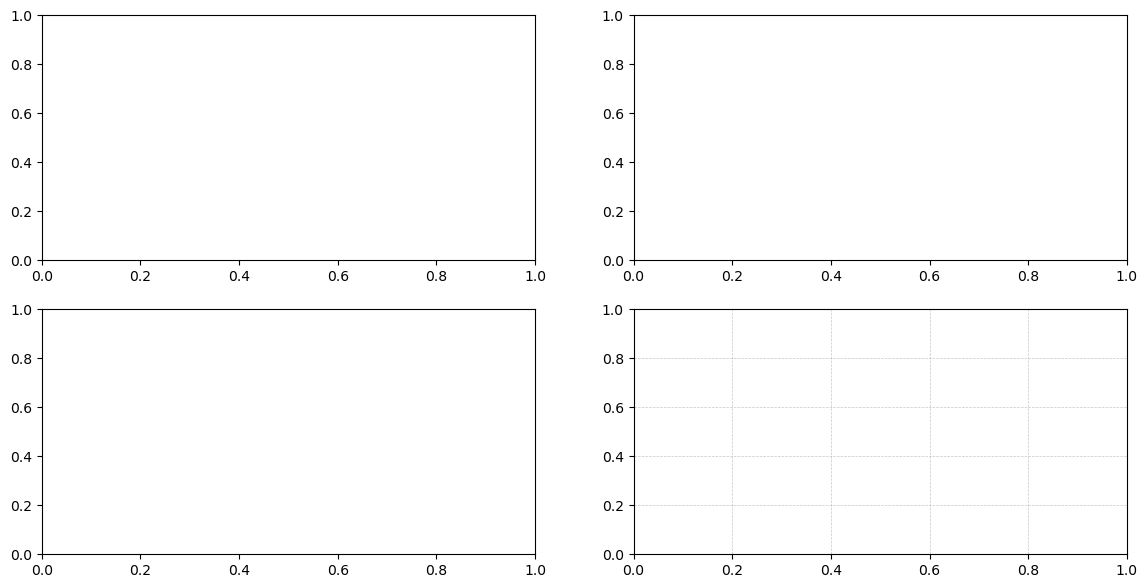

In [104]:


dfc = df[(df.sparsity_level >= 50) & (df.sparsity_level <= 100)]

fig = plt.figure(figsize=(14, 7))
axes = defaultdict(dict)
gs = fig.add_gridspec(2, 2) 
axes[0][2] = fig.add_subplot(gs[0, 0])
axes[1][2] = fig.add_subplot(gs[0, 1])
axes[0][3] = fig.add_subplot(gs[1, 0])
axes[1][3] = fig.add_subplot(gs[1, 1])
categories=[
        'DenseMM', 'SpMM_COO(Snack)', 'SpMM_COO(Cupy)' ,'SpMM_CSR(Cupy)', 'SpMM_CSR(Torch)', 'SpMM_BSR(Jax)', 'SpMM_COO(Torch)', "DenseMM+Mask" 
    ]
_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [1],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 1)",
    batch_needed=False,
    categories=categories,
    ax=axes[0][2]
)

_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [4],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 4)",
    batch_needed=False,
    categories=categories,
    ax=axes[1][2]
)


_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [16],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 16)",
    batch_needed=False,
       categories=categories,
    ax=axes[0][3]
)

_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [1, 32],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 32)",
    batch_needed=False,
       categories=categories,
    ax=axes[1][3],
    legend_place="lower left",
)
for k in axes.keys():
    for v in axes[k].values():
        v.legend().set_visible(False)
legend_labels = categories
legend_colors = plt.cm.tab10.colors
from matplotlib.patches import Patch

# Create custom legend handles
custom_handles = [Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]
fig.legend(handles=custom_handles,
           ncol=4,
          loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=True)

# plt.tight_layout(rect=[0, 0, 1, 0.95])
for ax in [ axes[0][3], axes[1][3]]:
    
    ax.set_xlabel('Sparsity')
axes[0][3].set_ylabel('CUDA time')
axes[0][2].set_ylabel('CUDA time')
plt.show()

fig.savefig("./figures/SpMM vs DenseMM-hor.pdf", bbox_inches='tight')
plt.show()

/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dlvl[col] = df_dlvl[col]  # .apply(lambda x: np.log2(x))
/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dlvl[col] = df_dlvl[col]  # .apply(lambda x: np.log2(x))
/tmp/ipykernel_11391/2771030349.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose 

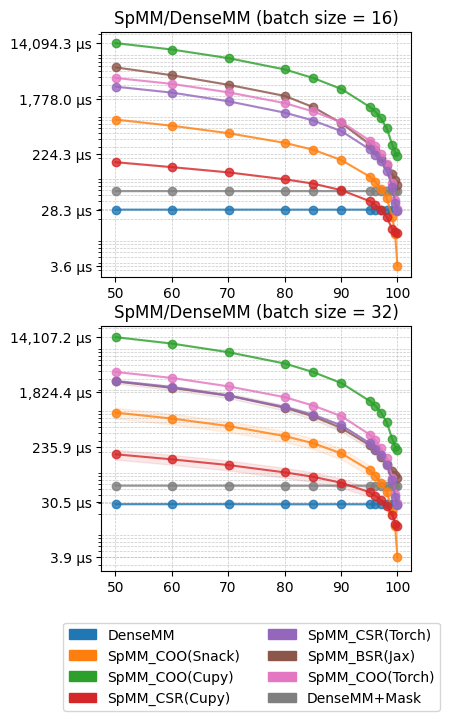

In [66]:


dfc = df[(df.sparsity_level >= 50) & (df.sparsity_level <= 100)]

fig = plt.figure(figsize=(4, 7))
axes = defaultdict(dict)
gs = fig.add_gridspec(2, 1) 
# axes[0][2] = fig.add_subplot(gs[0, 0])
# axes[1][2] = fig.add_subplot(gs[1, 0])
axes[0][3] = fig.add_subplot(gs[0, 0])
axes[1][3] = fig.add_subplot(gs[1, 0])
categories=[
        'DenseMM', 'SpMM_COO(Snack)', 'SpMM_COO(Cupy)' ,'SpMM_CSR(Cupy)', 'SpMM_CSR(Torch)', 'SpMM_BSR(Jax)', 'SpMM_COO(Torch)', "DenseMM+Mask" 
    ]
# _ = create_single_plot_for_batches(
#     dfc, 
#     dense_level, 
#     "cuda_elapsed_time",
#     [1],
#     figsize=(7, 5), 
#     log=True,
#     title="SpMM/DenseMM (batch size = 1)",
#     batch_needed=False,
#     categories=categories,
#     ax=axes[0][2]
# )

# _ = create_single_plot_for_batches(
#     dfc, 
#     dense_level, 
#     "cuda_elapsed_time",
#     [4],
#     figsize=(7, 5), 
#     log=True,
#     title="SpMM/DenseMM (batch size = 4)",
#     batch_needed=False,
#     categories=categories,
#     ax=axes[1][2]
# )


_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [16],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 16)",
    batch_needed=False,
       categories=categories,
    ax=axes[0][3]
)

_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [1, 32],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 32)",
    batch_needed=False,
       categories=categories,
    ax=axes[1][3],
    legend_place="lower left",
)
for k in axes.keys():
    for v in axes[k].values():
        v.legend().set_visible(False)
legend_labels = categories
legend_colors = plt.cm.tab10.colors
from matplotlib.patches import Patch

# Create custom legend handles
custom_handles = [Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]
fig.legend(handles=custom_handles,
           ncol=2,
          loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=True)

# plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig.savefig("./figures/SpMM vs DenseMM-p2.pdf", bbox_inches='tight')
plt.show()